# Nose Extraction with Landmark Lines
Extract and visualize nose part with facial landmark lines

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q torch transformers pillow matplotlib opencv-python protobuf==5.29.5 tensorflow==2.19.0 mediapipe==0.10.21

In [ ]:
# Install required packages
# !pip install -q torch transformers pillow matplotlib opencv-python mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.3 MB/s eta 0:00:00


In [ ]:
# !pip install protobuf==5.29.5
# !pip install tensorflow==2.19.0
# !pip install mediapipe==0.10.21

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 794.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.3 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 27.4 MB/s eta 0:0

KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import mediapipe as mp

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
# Load face parsing model from Google Drive
model_path = "/content/drive/MyDrive/face-parsing"

processor = SegformerImageProcessor.from_pretrained(model_path)
model = AutoModelForSemanticSegmentation.from_pretrained(model_path)
model.to(device)
model.eval()

print("Model loaded successfully!")

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
# Initialize MediaPipe Face Mesh for landmarks
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("Face Mesh initialized!")

Face Mesh initialized!


In [ ]:
# Upload image
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"Image uploaded: {image_path}")

Saving new-front.jpg to new-front.jpg
Image uploaded: new-front.jpg


Image shape: (425, 320, 3)


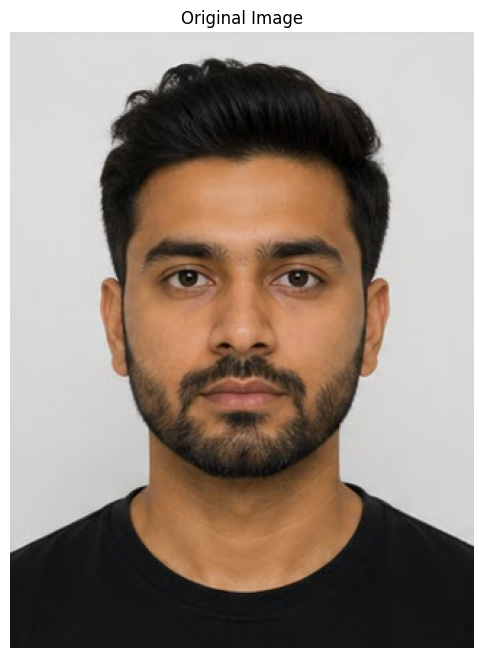

In [ ]:
# Load and process image
image = Image.open(image_path).convert("RGB")
img_array = np.array(image)
img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

print(f"Image shape: {img_array.shape}")

# Display original image
plt.figure(figsize=(8, 8))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
# Get face parsing segmentation
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Upsample to original image size
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

labels = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

print(f"Segmentation shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Segmentation shape: (425, 320)
Unique labels: [ 0  1  2  4  5  6  7  8  9 11 12 13 17 18]


In [ ]:
# Extract nose part (label 2 is nose)
nose_mask = (labels == 2).astype(np.uint8)

# Create nose image
nose_part = np.zeros_like(img_array)
nose_part[nose_mask == 1] = img_array[nose_mask == 1]

# Crop nose region
ys, xs = np.where(nose_mask)

if len(xs) > 0:
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    # Add padding
    pad = 20
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(img_array.shape[1], x2 + pad)
    y2 = min(img_array.shape[0], y2 + pad)

    nose_crop = img_array[y1:y2, x1:x2].copy()
    print(f"Nose crop shape: {nose_crop.shape}")
else:
    print("No nose detected")

Nose crop shape: (100, 87, 3)


In [ ]:
# Get face landmarks using MediaPipe
results = face_mesh.process(img_array)

h, w = img_array.shape[:2]
landmarks_px = None

if results.multi_face_landmarks:
    landmarks = results.multi_face_landmarks[0].landmark
    landmarks_px = np.array([[lm.x * w, lm.y * h] for lm in landmarks])
    print(f"Detected {len(landmarks)} facial landmarks")
else:
    print("No face detected")

Detected 478 facial landmarks


In [ ]:
# Define nose landmark indices (MediaPipe Facemesh)
NOSE_TIP = 4
NOSE_BRIDGE = 168
SUBNASALE = 2  # nose base
R_ALA = 129     # right nostril
L_ALA = 358     # left nostril
R_INNER_NOSTRIL = 236
L_INNER_NOSTRIL = 456

NOSE_LANDMARKS = [NOSE_TIP, NOSE_BRIDGE, SUBNASALE, R_ALA, L_ALA, R_INNER_NOSTRIL, L_INNER_NOSTRIL]

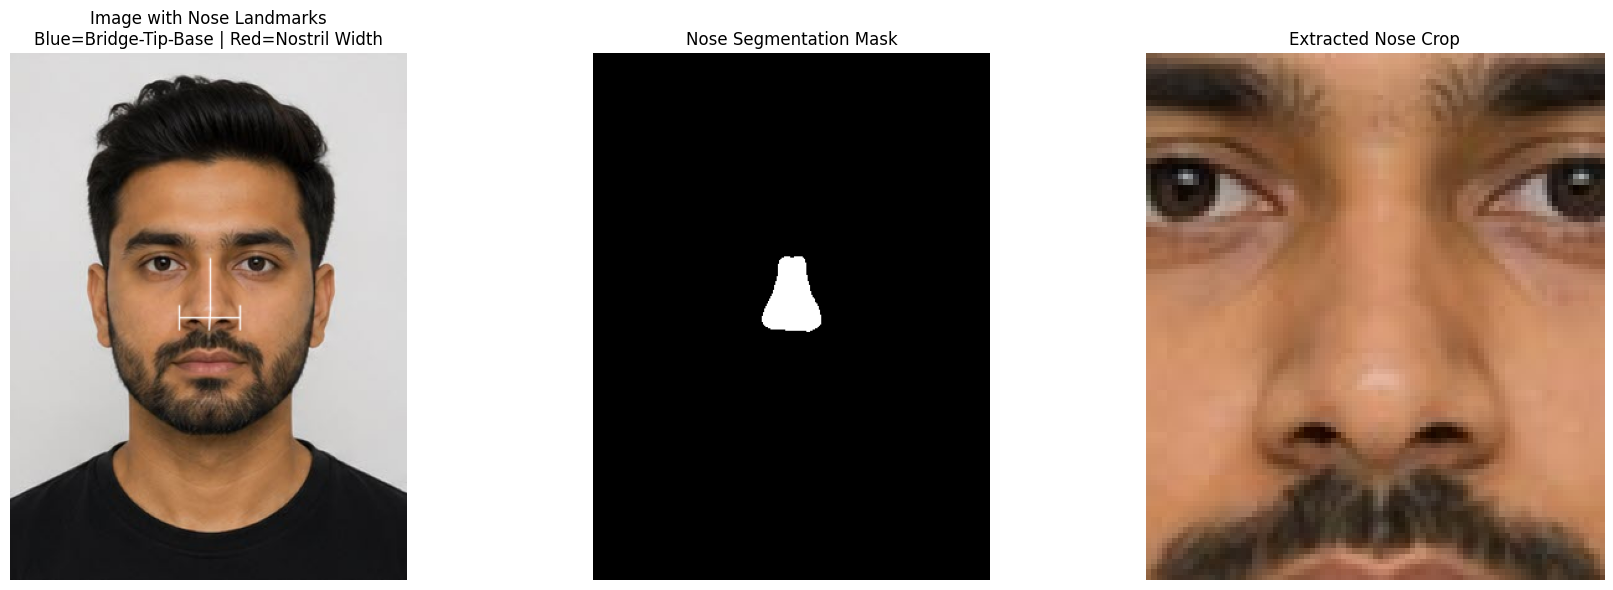

✓ Nose extraction complete!


In [ ]:
# Create visualization with nose extraction and lines
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original image with nose landmarks
img_with_landmarks = img_array.copy()
img_with_landmarks_bgr = img_bgr.copy()

if landmarks_px is not None:
    # Draw nose landmarks
    for idx in NOSE_LANDMARKS:
        pt = landmarks_px[idx].astype(int)
        # cv2.circle(img_with_landmarks_bgr, tuple(pt), 4, (0, 255, 0), -1)
        # cv2.circle(img_with_landmarks_bgr, tuple(pt), 5, (0, 255, 255), 2)

    # Draw nose structure lines
    # Center vertical line: bridge to base
    p_bridge = landmarks_px[NOSE_BRIDGE].astype(int)
    p_tip = landmarks_px[NOSE_TIP].astype(int)
    p_base = landmarks_px[SUBNASALE].astype(int)

    cv2.line(img_with_landmarks_bgr, tuple(p_bridge), tuple(p_tip), (255,255,255), 1, cv2.LINE_AA)
    cv2.line(img_with_landmarks_bgr, tuple(p_tip), tuple(p_base), (255,255,255), 1, cv2.LINE_AA)

    # Nostril width line
    p_r_ala = landmarks_px[R_ALA].astype(int)
    p_l_ala = landmarks_px[L_ALA].astype(int)
    cv2.line(img_with_landmarks_bgr, tuple(p_r_ala), tuple(p_l_ala), (255,255,255), 1, cv2.LINE_AA)

    # Draw end ticks for measurements
    tick_len = 10
    for pt in [p_r_ala, p_l_ala]:
        cv2.line(img_with_landmarks_bgr, (pt[0], pt[1] - tick_len), (pt[0], pt[1] + tick_len), (255,255,255), 1, cv2.LINE_AA)

axes[0].imshow(cv2.cvtColor(img_with_landmarks_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Image with Nose Landmarks\nBlue=Bridge-Tip-Base | Red=Nostril Width", fontsize=12)
axes[0].axis("off")

# 2. Nose segmentation mask
axes[1].imshow(nose_mask, cmap="gray")
axes[1].set_title("Nose Segmentation Mask", fontsize=12)
axes[1].axis("off")

# 3. Extracted nose crop
axes[2].imshow(nose_crop)
axes[2].set_title("Extracted Nose Crop", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("nose_extraction_result.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Nose extraction complete!")

In [ ]:
# Save individual outputs
cv2.imwrite("nose_with_landmarks.png", img_with_landmarks_bgr)
cv2.imwrite("nose_mask.png", nose_mask * 255)
cv2.imwrite("nose_crop.png", cv2.cvtColor(nose_crop, cv2.COLOR_RGB2BGR))

print("✓ Saved: nose_with_landmarks.png")
print("✓ Saved: nose_mask.png")
print("✓ Saved: nose_crop.png")

✓ Saved: nose_with_landmarks.png
✓ Saved: nose_mask.png
✓ Saved: nose_crop.png


In [ ]:
# Optional: Print nose measurements
if landmarks_px is not None:
    p_r_ala = landmarks_px[R_ALA]
    p_l_ala = landmarks_px[L_ALA]
    p_bridge = landmarks_px[NOSE_BRIDGE]
    p_base = landmarks_px[SUBNASALE]

    nose_width = np.linalg.norm(p_r_ala - p_l_ala)
    nose_height = np.linalg.norm(p_base - p_bridge)

    print("\n=== NOSE MEASUREMENTS ===")
    print(f"Nostril width (pixels): {nose_width:.2f}")
    print(f"Nose height (pixels): {nose_height:.2f}")
    print(f"Nasal aspect ratio (width/height): {nose_width/nose_height:.2f}")


=== NOSE MEASUREMENTS ===
Nostril width (pixels): 49.37
Nose height (pixels): 58.14
Nasal aspect ratio (width/height): 0.85


In [ ]:
# ============================================================
# ALAR FLARE ANALYSIS - Draw circles on nostrils with assessment
# ============================================================

def draw_nostril_circles_with_analysis(img_array, landmarks_px):
    """
    Draw circles around nostrils and provide Alar Flare assessment
    """

    # Nose landmark indices
    NOSE_TIP = 4
    NOSE_BRIDGE = 168
    SUBNASALE = 2       # nose base center
    R_ALA = 129         # right nostril wing
    L_ALA = 358         # left nostril wing
    R_INNER_CANTHUS = 133  # right inner eye corner
    L_INNER_CANTHUS = 362  # left inner eye corner

    # Get landmark positions
    p_r_ala = landmarks_px[R_ALA].astype(np.float32)
    p_l_ala = landmarks_px[L_ALA].astype(np.float32)
    p_nose_base = landmarks_px[SUBNASALE].astype(np.float32)
    p_r_eye = landmarks_px[R_INNER_CANTHUS].astype(np.float32)
    p_l_eye = landmarks_px[L_INNER_CANTHUS].astype(np.float32)
    p_nose_tip = landmarks_px[NOSE_TIP].astype(np.float32)

    # Convert to BGR for OpenCV
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    overlay = img_bgr.copy()

    # ============================================================
    # Calculate Alar Flare metrics
    # ============================================================

    # Ideal: alar bases should align with inner eye corners (vertical lines)
    eye_vertical_distance = abs(p_r_eye[0] - p_l_eye[0])
    alar_distance = abs(p_r_ala[0] - p_l_ala[0])

    # Calculate how much the alar bases deviate outward
    ideal_r_x = p_r_eye[0]
    ideal_l_x = p_l_eye[0]

    r_alar_deviation = p_r_ala[0] - ideal_r_x
    l_alar_deviation = ideal_l_x - p_l_ala[0]

    alar_flare_ratio = alar_distance / (eye_vertical_distance + 1e-9)

    # Determine assessment
    if alar_flare_ratio < 0.95:
        assessment = "No Alar Flare"
        color_circle = (0, 255, 0)  # Green for good
    elif alar_flare_ratio < 1.1:
        assessment = "Mild Alar Flare"
        color_circle = (0, 165, 255)  # Orange for mild
    else:
        assessment = "Significant Alar Flare"
        color_circle = (255, 255, 255)  # Red for significant

    # ============================================================
    # Draw circles around nostrils
    # ============================================================

    # Calculate radius based on nostril size
    r_radius = int(np.linalg.norm(p_r_ala - p_nose_tip) * 0.2)
    l_radius = int(np.linalg.norm(p_l_ala - p_nose_tip) * 0.2)

    # Ensure minimum radius
    r_radius = max(r_radius, 7)
    l_radius = max(l_radius, 7)

    # Draw circles
    cv2.circle(overlay, tuple(p_r_ala.astype(int)), r_radius, color_circle, 1, cv2.LINE_AA)
    cv2.circle(overlay, tuple(p_l_ala.astype(int)), l_radius, color_circle, 1, cv2.LINE_AA)

    # ============================================================
    # Create figure with image and text analysis
    # ============================================================

    fig = plt.figure(figsize=(16, 8))

    # Left subplot: Image with circles
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax1.set_title("Nostril Analysis", fontsize=14, fontweight='bold')
    ax1.axis("off")

    # Right subplot: Assessment text
    ax2 = plt.subplot(1, 2, 2)
    ax2.axis("off")

    # Title
    ax2.text(0.5, 0.95, assessment,
             fontsize=28, fontweight='bold',
             ha='center', va='top',
             color=tuple(c/255 for c in [color_circle[2], color_circle[1], color_circle[0]]),
             transform=ax2.transAxes)

    # Separator
    ax2.plot([0.1, 0.9], [0.88, 0.88], 'k-', linewidth=2, transform=ax2.transAxes)

    # Explanation header
    ax2.text(0.5, 0.80, "EXPLANATION",
             fontsize=16, fontweight='bold',
             ha='center', va='top',
             transform=ax2.transAxes)

    # Explanation text
    explanation_text = (
        "Your alar bases stay close to vertical lines from "
        "the inner eye corners so the base does not widen "
        "laterally and the nostril wings do not dominate "
        "the lower face."
    )

    ax2.text(0.5, 0.68, explanation_text,
             fontsize=12, ha='center', va='top',
             wrap=True, multialignment='center',
             transform=ax2.transAxes,
             bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', alpha=0.7))

    # Metrics section
    ax2.text(0.5, 0.40, "METRICS",
             fontsize=14, fontweight='bold',
             ha='center', va='top',
             transform=ax2.transAxes)

    metrics_text = (
        f"Alar Width: {alar_distance:.1f} px\n"
        f"Eye Width: {eye_vertical_distance:.1f} px\n"
        f"Alar Flare Ratio: {alar_flare_ratio:.2f}\n"
        f"R Alar Deviation: {r_alar_deviation:+.1f} px\n"
        f"L Alar Deviation: {l_alar_deviation:+.1f} px"
    )

    ax2.text(0.5, 0.30, metrics_text,
             fontsize=11, ha='center', va='top',
             family='monospace',
             transform=ax2.transAxes,
             bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.5))

    # Legend
    legend_text = (
        "● Green: No Alar Flare (Ratio < 0.95)\n"
        "● Orange: Mild Alar Flare (0.95-1.1)\n"
        "● Red: Significant Alar Flare (> 1.1)"
    )

    ax2.text(0.5, 0.08, legend_text,
             fontsize=10, ha='center', va='top',
             transform=ax2.transAxes,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgray', alpha=0.3))

    plt.tight_layout()
    plt.savefig("alar_flare_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Save the overlay image
    cv2.imwrite("nostril_circles_overlay.png", overlay)

    # Print summary
    print("\n" + "="*60)
    print("ALAR FLARE ANALYSIS RESULTS")
    print("="*60)
    print(f"Assessment: {assessment}")
    print(f"\nMeasurements:")
    print(f"  - Alar Width (nostril to nostril):     {alar_distance:.2f} px")
    print(f"  - Eye Width (inner corners):           {eye_vertical_distance:.2f} px")
    print(f"  - Alar Flare Ratio:                    {alar_flare_ratio:.3f}")
    print(f"  - Right Alar Deviation:                {r_alar_deviation:+.2f} px")
    print(f"  - Left Alar Deviation:                 {l_alar_deviation:+.2f} px")
    print(f"\nInterpretation:")
    print(f"  Ratio < 0.95: No flare (alar narrower than eyes)")
    print(f"  Ratio 0.95-1.1: Mild flare (alar similar to eye width)")
    print(f"  Ratio > 1.1: Significant flare (alar wider than eyes)")
    print("="*60 + "\n")

    return overlay, assessment, alar_flare_ratio

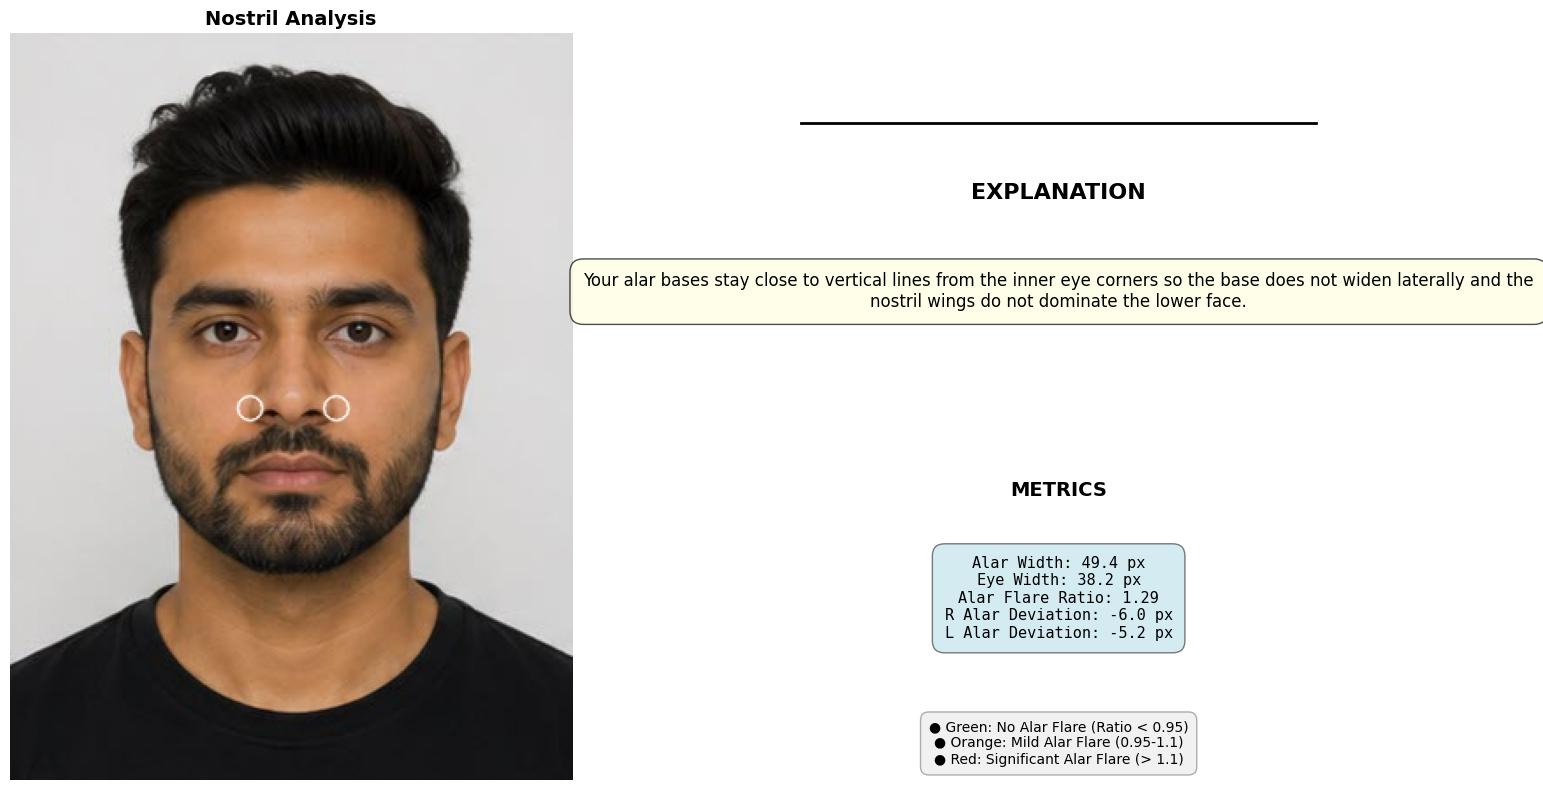


ALAR FLARE ANALYSIS RESULTS
Assessment: Significant Alar Flare

Measurements:
  - Alar Width (nostril to nostril):     49.37 px
  - Eye Width (inner corners):           38.19 px
  - Alar Flare Ratio:                    1.293
  - Right Alar Deviation:                -6.00 px
  - Left Alar Deviation:                 -5.18 px

Interpretation:
  Ratio < 0.95: No flare (alar narrower than eyes)
  Ratio 0.95-1.1: Mild flare (alar similar to eye width)
  Ratio > 1.1: Significant flare (alar wider than eyes)

✓ Analysis complete! Assessment: Significant Alar Flare


In [ ]:
# Run the Alar Flare Analysis
if landmarks_px is not None:
    overlay, assessment, ratio = draw_nostril_circles_with_analysis(img_array, landmarks_px)
    print(f"✓ Analysis complete! Assessment: {assessment}")
else:
    print("No landmarks detected. Please check your image.")

In [ ]:


def catmull_rom_spline(points, n_points=100):
    """Smooth a closed polygon through its corner points using Catmull-Rom spline."""
    points = np.array(points, dtype=np.float32)
    p = np.vstack([points[-1], points, points[0], points[1]])  # wrap for closed curve
    curve = []
    for i in range(1, len(p) - 2):
        p0, p1, p2, p3 = p[i - 1], p[i], p[i + 1], p[i + 2]
        for t in np.linspace(0, 1, n_points // len(points), endpoint=False):
            t2, t3 = t * t, t * t * t
            pt = 0.5 * (
                (2 * p1)
                + (-p0 + p2) * t
                + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t2
                + (-p0 + 3 * p1 - 3 * p2 + p3) * t3
            )
            curve.append(pt)
    return np.array(curve, dtype=np.int32)


def draw_bridge_thickness_analysis(img_array, landmarks_px):
    """
    Draw an outline over the nasal bridge region and provide a
    Bridge Thickness assessment, matching the reference style.
    """

    # ---- Bridge region landmarks (MediaPipe Face Mesh) ----
    UPPER_LEFT   = 193   # upper bridge sidewall, right-of-image / anatomical right
    UPPER_RIGHT  = 417   # upper bridge sidewall, left-of-image / anatomical left
    LOWER_RIGHT  = 456   # lower bridge / pyramidal sidewall (left)
    LOWER_LEFT   = 236   # lower bridge / pyramidal sidewall (right)
    NOSE_BRIDGE  = 168
    GLABELLA     = 9

    p_ul = landmarks_px[UPPER_LEFT].astype(np.float32)
    p_ur = landmarks_px[UPPER_RIGHT].astype(np.float32)
    p_lr = landmarks_px[LOWER_RIGHT].astype(np.float32)
    p_ll = landmarks_px[LOWER_LEFT].astype(np.float32)
    p_bridge = landmarks_px[NOSE_BRIDGE].astype(np.float32)
    p_glabella = landmarks_px[GLABELLA].astype(np.float32)

    # ---- Bridge thickness metric ----
    # width at top of bridge vs width lower down the bridge, normalized
    # by face-independent reference (glabella-to-bridge vertical span)
    upper_width = np.linalg.norm(p_ul - p_ur)
    lower_width = np.linalg.norm(p_ll - p_lr)
    bridge_span = np.linalg.norm(p_glabella - p_bridge) + 1e-9

    thickness_ratio = ((upper_width + lower_width) / 2) / bridge_span

    # Simple 3-band classification (tune thresholds as needed)
    if thickness_ratio < 0.55:
        assessment = "Thin Bridge"
        text_color = (0, 165, 255)   # orange
    elif thickness_ratio <= 0.85:
        assessment = "Normal Bridge Thickness"
        text_color = (0, 255, 0)     # green
    else:
        assessment = "Wide / Padded Bridge"
        text_color = (0, 165, 255)   # orange

    explanation_text = (
        "Your bridge thickness sits in a normal range so the subtle "
        "hump reads clearly without looking either bony-thin or "
        "padded and the midline feels structurally firm."
    )

    # ---- Draw the rounded outline over the bridge ----
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    overlay = img_bgr.copy()

    # slight outward padding so the outline sits just outside the bridge edges
    pad_x, pad_top, pad_bottom = 6, 10, 6
    corners = [
        p_ul + np.array([-pad_x, -pad_top]),
        p_ur + np.array([ pad_x, -pad_top]),
        p_lr + np.array([ pad_x,  pad_bottom]),
        p_ll + np.array([-pad_x,  pad_bottom]),
    ]

    smooth_curve = catmull_rom_spline(corners, n_points=120)
    line_color = (235, 235, 250)  # light cream/white, BGR

    cv2.polylines(overlay, [smooth_curve], isClosed=True,
                  color=line_color, thickness=1, lineType=cv2.LINE_AA)

    # ============================================================
    # Figure: image + text panel (same layout as prior analyses)
    # ============================================================
    fig = plt.figure(figsize=(16, 8))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax1.set_title("Bridge Thickness Analysis", fontsize=14, fontweight='bold')
    ax1.axis("off")

    ax2 = plt.subplot(1, 2, 2)
    ax2.axis("off")

    ax2.text(0.5, 0.95, assessment,
              fontsize=26, fontweight='bold',
              ha='center', va='top',
              color=tuple(c / 255 for c in [text_color[2], text_color[1], text_color[0]]),
              transform=ax2.transAxes)

    ax2.plot([0.1, 0.9], [0.86, 0.86], 'k-', linewidth=1, transform=ax2.transAxes)

    ax2.text(0.5, 0.78, "EXPLANATION",
              fontsize=16, fontweight='bold',
              ha='center', va='top',
              transform=ax2.transAxes)

    ax2.text(0.5, 0.66, explanation_text,
              fontsize=12, ha='center', va='top',
              wrap=True, multialignment='center',
              transform=ax2.transAxes,
              bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', alpha=0.7))

    ax2.text(0.5, 0.38, "METRICS",
              fontsize=14, fontweight='bold',
              ha='center', va='top',
              transform=ax2.transAxes)

    metrics_text = (
        f"Upper Bridge Width: {upper_width:.1f} px\n"
        f"Lower Bridge Width: {lower_width:.1f} px\n"
        f"Bridge Vertical Span: {bridge_span:.1f} px\n"
        f"Thickness Ratio: {thickness_ratio:.2f}"
    )

    ax2.text(0.5, 0.28, metrics_text,
              fontsize=11, ha='center', va='top',
              family='monospace',
              transform=ax2.transAxes,
              bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.5))

    legend_text = (
        "Ratio < 0.55: Thin Bridge\n"
        "Ratio 0.55-0.85: Normal Bridge Thickness\n"
        "Ratio > 0.85: Wide / Padded Bridge"
    )

    ax2.text(0.5, 0.08, legend_text,
              fontsize=10, ha='center', va='top',
              transform=ax2.transAxes,
              bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgray', alpha=0.3))

    plt.tight_layout()
    plt.savefig("bridge_thickness_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

    cv2.imwrite("bridge_outline_overlay.png", overlay)

    print("\n" + "=" * 60)
    print("BRIDGE THICKNESS ANALYSIS RESULTS")
    print("=" * 60)
    print(f"Assessment: {assessment}")
    print(f"\nMeasurements:")
    print(f"  - Upper Bridge Width:      {upper_width:.2f} px")
    print(f"  - Lower Bridge Width:      {lower_width:.2f} px")
    print(f"  - Bridge Vertical Span:    {bridge_span:.2f} px")
    print(f"  - Thickness Ratio:         {thickness_ratio:.3f}")
    print("=" * 60 + "\n")

    return overlay, assessment, thickness_ratio

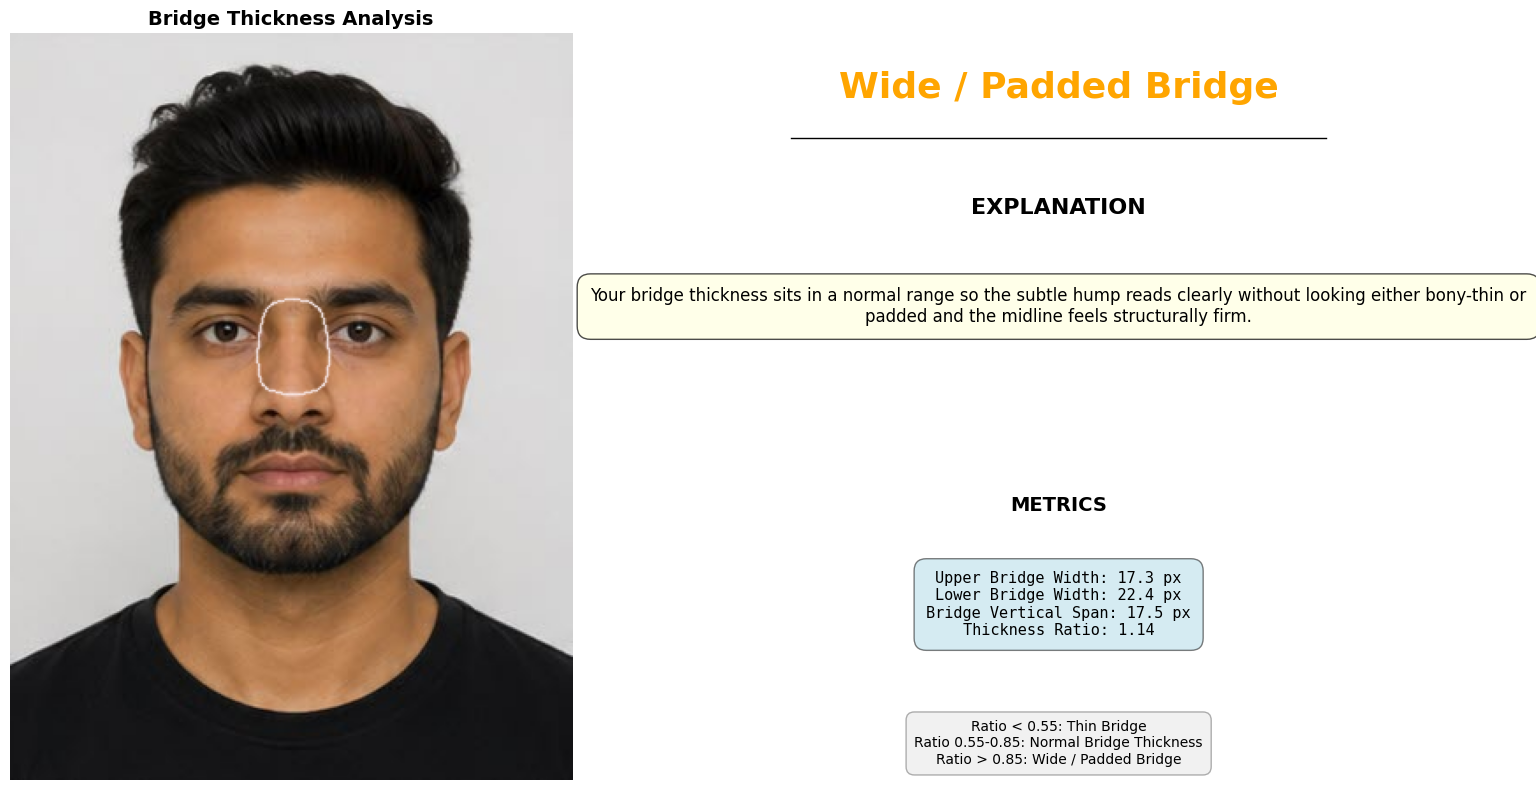


BRIDGE THICKNESS ANALYSIS RESULTS
Assessment: Wide / Padded Bridge

Measurements:
  - Upper Bridge Width:      17.33 px
  - Lower Bridge Width:      22.45 px
  - Bridge Vertical Span:    17.51 px
  - Thickness Ratio:         1.136



In [ ]:

if landmarks_px is not None:
    overlay, assessment, ratio = draw_bridge_thickness_analysis(img_array, landmarks_px)
else:
    print("No landmarks detected. Please check your image.")